In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

path = 'data.csv'

try:
    df = pd.read_csv(path)
    print(" Dataset cargado correctamente")
    print(df.info())
except FileNotFoundError:
    print(" Error: No se encontró 'data.csv'. Verifica el nombre en tu carpeta.")

 Dataset cargado correctamente
<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       503 non-null    str    
 1   Open       503 non-null    float64
 2   High       503 non-null    float64
 3   Low        503 non-null    float64
 4   Close      503 non-null    float64
 5   Adj Close  503 non-null    float64
 6   Volume     503 non-null    int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 27.6 KB
None


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(len(series), y, "bx", markersize=10, label="Real")
    if y_pred is not None:
        plt.plot(len(series), y_pred, "ro", label="Pred")
    plt.grid(True)
    if x_label: plt.xlabel(x_label, fontsize=12)
    if y_label: plt.ylabel(y_label, fontsize=12)
    plt.legend()

In [ ]:
df_num = df.select_dtypes(include=[np.number]).interpolate().dropna()
df_num['target'] = (df_num['Close'].shift(-1) > df_num['Close']).astype(int)
df_num = df_num.dropna() 
features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_num[features])
labels = df_num['target'].values


In [5]:
def create_windows(data, labels, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(labels[i+window_size])
    return np.array(X).astype(np.float32), np.array(y).astype(np.int64)

X, y = create_windows(data_scaled, labels)

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, ix): return self.X[ix], self.y[ix]

split = int(0.8 * len(X))
train_ds = TimeSeriesDataset(X[:split], y[:split])
test_ds = TimeSeriesDataset(X[split:], y[split:])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)


In [ ]:
class RNNModel(nn.Module):
    def __init__(self, n_features, method='LSTM'):
        super().__init__()
        if method == 'LSTM':
            self.rnn = nn.LSTM(n_features, 50, batch_first=True)
        else:
            self.rnn = nn.GRU(n_features, 50, batch_first=True)
        self.fc = nn.Linear(50, 2) 
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]) 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

def train_model(name='LSTM'):
    model = RNNModel(n_features=len(features), method=name).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'acc': []}
    
    print(f" Entrenando {name}...")
    for epoch in range(60): 
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
            
        history['loss'].append(train_loss / len(train_loader))
        history['acc'].append(correct / total)
        
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    return history, y_true, y_pred

hist_lstm, true_lstm, pred_lstm = train_model('LSTM')
hist_gru, true_gru, pred_gru = train_model('GRU')

 Entrenando LSTM...
 Entrenando GRU...


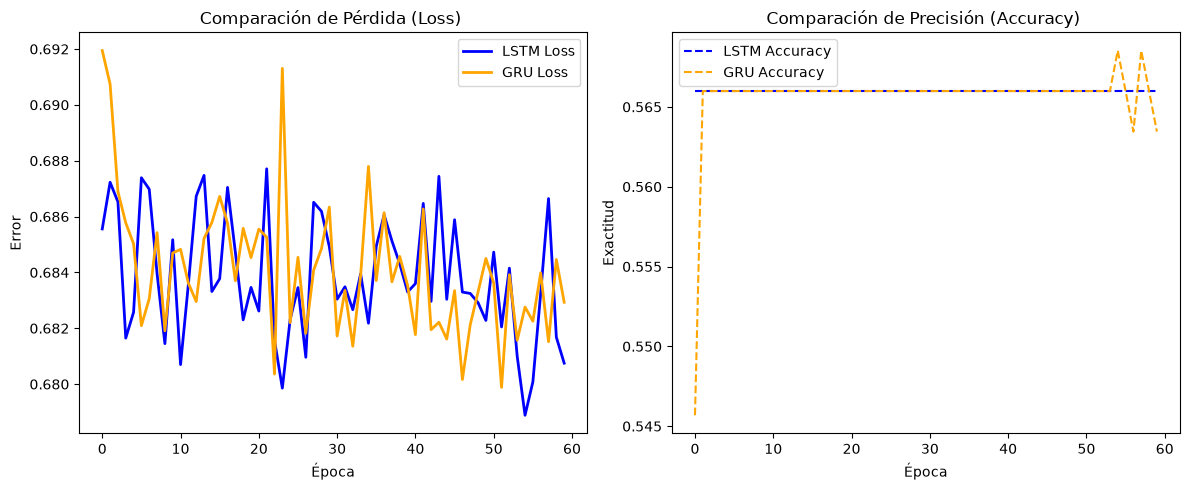

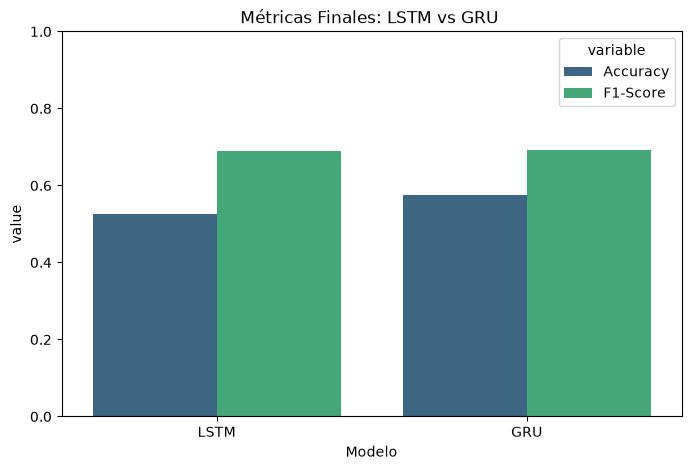

Métricas Detalladas:
  Modelo  Accuracy  F1-Score
0   LSTM  0.525253  0.688742
1    GRU  0.575758  0.691176


In [12]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_lstm['loss'], label='LSTM Loss', color='blue', lw=2)
plt.plot(hist_gru['loss'], label='GRU Loss', color='orange', lw=2)
plt.title('Comparación de Pérdida (Loss) ')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_lstm['acc'], label='LSTM Accuracy', color='blue', linestyle='--')
plt.plot(hist_gru['acc'], label='GRU Accuracy', color='orange', linestyle='--')
plt.title('Comparación de Precisión (Accuracy) ')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.tight_layout()
plt.show()

metrics = {
    'Modelo': ['LSTM', 'GRU'],
    'Accuracy': [accuracy_score(true_lstm, pred_lstm), accuracy_score(true_gru, pred_gru)],
    'F1-Score': [f1_score(true_lstm, pred_lstm), f1_score(true_gru, pred_gru)]
}
df_metrics = pd.DataFrame(metrics)

plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='value', hue='variable', data=pd.melt(df_metrics, id_vars='Modelo'), palette='viridis')
plt.title('Métricas Finales: LSTM vs GRU ')
plt.ylim(0, 1)
plt.show()

print("Métricas Detalladas:")
print(df_metrics)

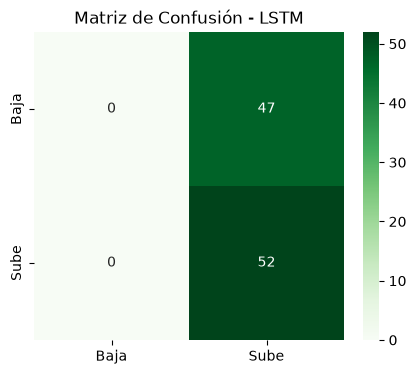

c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Reporte LSTM:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.53      1.00      0.69        52

    accuracy                           0.53        99
   macro avg       0.26      0.50      0.34        99
weighted avg       0.28      0.53      0.36        99



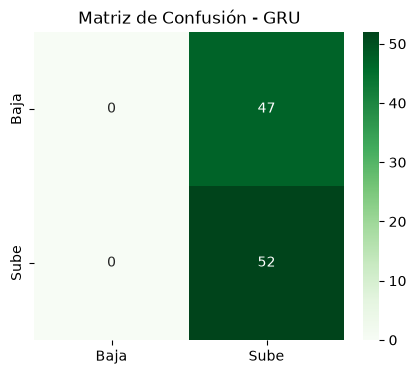

Reporte GRU:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.53      1.00      0.69        52

    accuracy                           0.53        99
   macro avg       0.26      0.50      0.34        99
weighted avg       0.28      0.53      0.36        99



c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\72828\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def train_and_eval(name='LSTM'):
    model = RNNModel(n_features=len(features), method=name).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(20):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Baja', 'Sube'], yticklabels=['Baja', 'Sube'])
    plt.title(f'Matriz de Confusión - {name}')
    plt.show()
    print(f"Reporte {name}:\n", classification_report(y_true, y_pred))

train_and_eval('LSTM')
train_and_eval('GRU')